# 🌊 Day 4 — Data Cleaning & Feature Engineering
## Caspian Maritime Delay-Risk Forecasting

**Builds on:** Day 3 — raw tables loaded in DuckDB (`raw.weather_daily`, `raw.visibility_daily`)

---

### ⚠️ Change from previous days

Date range is now **2022-01-01 → 2024-12-31** (3 years, all-real data).

| Reason | Detail |
|--------|--------|
| Visibility not in ERA5 archive | `visibility_*` nulls for 2015–2021 |
| Synthetic `fog_proxy` pre-2022 | Would teach the model a synthetic pattern, not a real one |
| Historical Forecast API starts 2022 | Visibility available for all 3 years of the new window |

If Day 2/3 databases still have pre-2022 data, a re-ingestion is required first (see the setup cell).

---

### 📌 Today's Agenda

| # | Task |
|---|------|
| 1 | Data Quality Assessment (missingness, outliers, gaps, consistency) |
| 2 | Run Cleaning Pipeline → `staging.weather_daily` |
| 3 | Run Feature Engineering → `analytics.daily_enriched`, `analytics.monthly_summary` |
| 4 | Verify target distribution |
| 5 | Summary + handoff to Day 5 |

---
## 0 — Environment Setup

In [6]:
import sys, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S',
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

from src.config import (
    CITIES, PATHS, DATE_RANGE, RISK_THRESHOLDS,
    OUTLIER_FLAG_COLUMNS, WINSORIZE_CAPS, HIGH_RISK_MONTH_THRESHOLD,
)
from src.database import get_connection, run_query
from src.cleaning import (
    handle_missing_values, flag_outliers, winsorize_by_city,
    validate_date_continuity, clean_raw_to_staging,
)
from src.features import (
    engineer_all_features, build_analytics_layer,
)

DB_PATH = PATHS['repo_root'] / 'data' / 'caspian_weather.duckdb'
print(f'📅 Date range: {DATE_RANGE["start"]} → {DATE_RANGE["end"]}')
print(f'💾 Database : {DB_PATH}')
print(f'✅ Ready')

📅 Date range: 2015-01-01 → 2024-12-31
💾 Database : C:\Users\user\project\data\caspian_weather.duckdb
✅ Ready


In [7]:
# Connect to the database built in Day 3
conn = get_connection(DB_PATH)

# Sanity check — does raw data respect the new 2022-2024 window?
print('=== Current raw data range ===')
print(run_query(conn, '''
    SELECT city,
           COUNT(*) AS rows,
           MIN(date) AS first_date,
           MAX(date) AS last_date
    FROM raw.weather_daily
    GROUP BY city
    ORDER BY city
''').to_string(index=False))

# Warning if pre-2022 data is present
pre_2022 = conn.execute(
    "SELECT COUNT(*) FROM raw.weather_daily WHERE date < '2022-01-01'"
).fetchone()[0]

if pre_2022 > 0:
    print(f'\n⚠️  {pre_2022} pre-2022 rows detected.')
    print('   Re-ingest with the updated DATE_RANGE (Day 2 notebook) before proceeding.')
    print('   Day 4 assumes 2022-01-01 to 2024-12-31 only.')

11:52:18  INFO      Connected to DuckDB: C:\Users\user\project\data\caspian_weather.duckdb
=== Current raw data range ===
        city  rows first_date  last_date
       Aktau  2192 2019-01-01 2024-12-31
      Anzali  2192 2019-01-01 2024-12-31
        Baku  2192 2019-01-01 2024-12-31
 Makhachkala  2192 2019-01-01 2024-12-31
Turkmenbashi  2192 2019-01-01 2024-12-31

⚠️  5480 pre-2022 rows detected.
   Re-ingest with the updated DATE_RANGE (Day 2 notebook) before proceeding.
   Day 4 assumes 2022-01-01 to 2024-12-31 only.


---
## 1 — Data Quality Assessment

Systematic checks on raw data: missingness, outliers, gaps, consistency, sensor artefacts.

### 1.1 — Missing Values

In [8]:
# Pull joined raw data for the quality assessment
raw_df = conn.execute('''
    SELECT w.*,
           v.visibility_mean, v.visibility_min,
           v.visibility_hours_below_1km
    FROM raw.weather_daily w
    LEFT JOIN raw.visibility_daily v
        ON w.city = v.city AND w.date = v.date
    ORDER BY w.city, w.date
''').fetchdf()

print(f'Total rows: {len(raw_df):,}  |  cities: {raw_df["city"].nunique()}')
print()

# Null counts per column
null_counts = raw_df.isnull().sum()
null_pct = (null_counts / len(raw_df) * 100).round(2)
null_summary = pd.DataFrame({
    'nulls': null_counts, 'pct': null_pct
})
null_summary = null_summary[null_summary['nulls'] > 0]

if null_summary.empty:
    print('✅ No missing values detected.')
else:
    print('Columns with nulls:')
    print(null_summary.to_string())

Total rows: 10,960  |  cities: 5

Columns with nulls:
                            nulls   pct
visibility_mean              5480  50.0
visibility_min               5480  50.0
visibility_hours_below_1km   5480  50.0


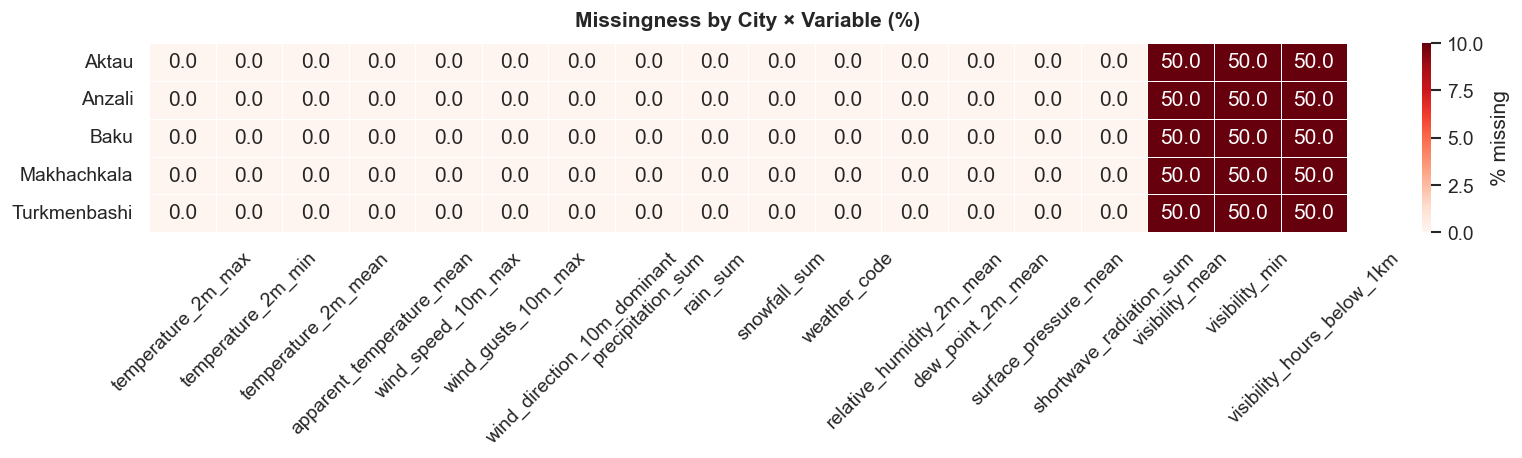

In [9]:
# Missingness heatmap per (city × variable)
missing_by_city = raw_df.groupby('city').apply(
    lambda g: g.select_dtypes('number').isna().mean() * 100
).round(2)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    missing_by_city, annot=True, fmt='.1f', cmap='Reds',
    vmin=0, vmax=10, linewidths=0.3, linecolor='white',
    cbar_kws={'label': '% missing'}, ax=ax,
)
ax.set_title('Missingness by City × Variable (%)', fontweight='bold', pad=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day04_missingness_heatmap.png', bbox_inches='tight')
plt.show()

### 1.2 — Outliers (per-city, IQR method)

We examine five key variables where outliers can mislead the model.

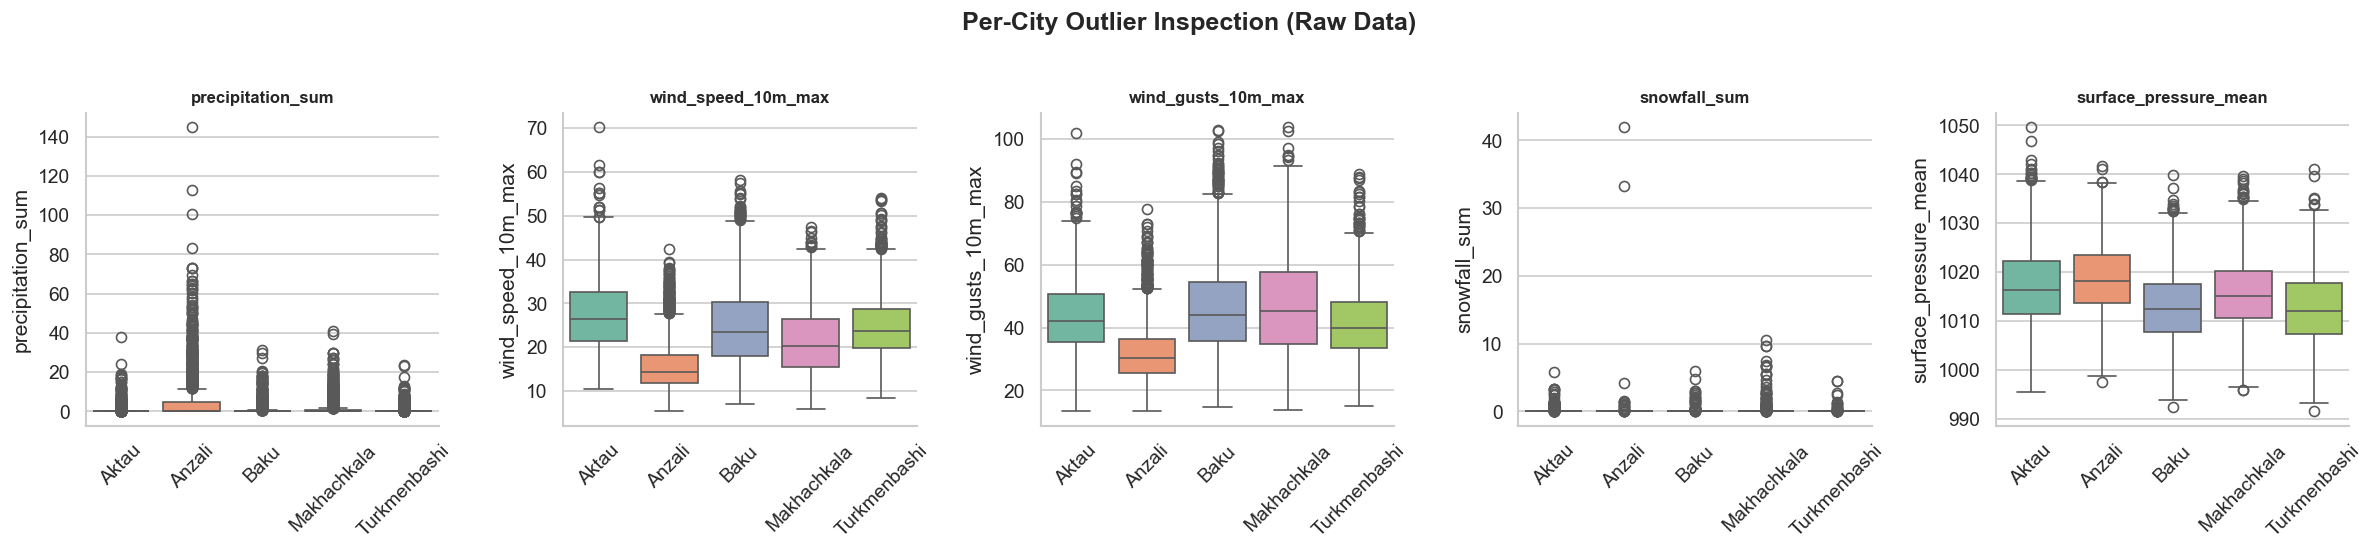


Key finding — precipitation distribution per city:
              mean    std  50%  75%    max
city                                      
Aktau         0.54   2.00  0.0  0.1   38.0
Anzali        5.05  11.26  0.1  4.7  144.7
Baku          0.85   2.56  0.0  0.3   31.5
Makhachkala   1.30   3.59  0.0  0.7   41.1
Turkmenbashi  0.40   1.53  0.0  0.0   23.7


In [10]:
focus_vars = ['precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
              'snowfall_sum', 'surface_pressure_mean']

fig, axes = plt.subplots(1, len(focus_vars), figsize=(4 * len(focus_vars), 4.5))
city_colors = dict(zip(
    raw_df['city'].unique(),
    sns.color_palette('Set2', n_colors=raw_df['city'].nunique()),
))

for i, var in enumerate(focus_vars):
    ax = axes[i]
    sns.boxplot(data=raw_df, x='city', y=var, ax=ax,
                palette=city_colors, showfliers=True)
    ax.set_title(var, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Per-City Outlier Inspection (Raw Data)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day04_boxplots.png', bbox_inches='tight')
plt.show()

print('\nKey finding — precipitation distribution per city:')
print(raw_df.groupby('city')['precipitation_sum'].describe()[['mean', 'std', '50%', '75%', 'max']].round(2).to_string())

**Anzali** clearly has a heavier precipitation tail than the other four cities — it sits on the Caspian's southern shore with orographic rainfall from the Alborz Mountains. Without winsorizing, its tail will dominate cross-city statistics and skew the model's risk threshold.

### 1.3 — Temporal Gaps

In [11]:
continuity = validate_date_continuity(raw_df)
print(f'Continuity status: {continuity["status"]}')
print(f'Expected total days: {continuity["total_expected"]:,}')
print(f'Actual total days:   {continuity["total_actual"]:,}')
print()
gaps_summary = pd.DataFrame({
    'city': continuity['checked_cities'],
    'gap_days': [continuity['gap_count'][c] for c in continuity['checked_cities']],
})
print(gaps_summary.to_string(index=False))

if continuity['status'] != '✅ OK':
    print('\n⚠️  Gaps detected. First 3 missing dates per city:')
    for city in continuity['checked_cities']:
        if continuity['gap_count'][city] > 0:
            print(f'  {city}: {continuity["gaps"][city][:3]}')

Continuity status: ✅ OK
Expected total days: 10,960
Actual total days:   10,960

        city  gap_days
       Aktau         0
      Anzali         0
        Baku         0
 Makhachkala         0
Turkmenbashi         0


### 1.4 — Forecast vs Historical Consistency

In [12]:
# If forecast data is loaded, compare overlapping dates
try:
    overlap = conn.execute('''
        SELECT h.city, h.date,
               h.wind_speed_10m_max AS hist_wind,
               f.wind_speed_10m_max AS fcast_wind,
               h.temperature_2m_max AS hist_temp,
               f.temperature_2m_max AS fcast_temp
        FROM raw.weather_daily h
        INNER JOIN raw.forecast_7day f
            ON h.city = f.city AND h.date = f.date
    ''').fetchdf()
    
    if len(overlap) > 0:
        print(f'Overlapping days: {len(overlap)}')
        overlap['wind_diff'] = (overlap['fcast_wind'] - overlap['hist_wind']).abs()
        overlap['temp_diff'] = (overlap['fcast_temp'] - overlap['hist_temp']).abs()
        print(f'\nMean abs wind difference: {overlap["wind_diff"].mean():.2f} km/h')
        print(f'Mean abs temp difference: {overlap["temp_diff"].mean():.2f} °C')
        print()
        if overlap['wind_diff'].mean() < 10 and overlap['temp_diff'].mean() < 5:
            print('✅ Historical & forecast agree within expected noise.')
        else:
            print('⚠️  Larger-than-expected mismatch — investigate model runs.')
    else:
        print('ℹ️  No overlapping dates between historical and forecast (expected for fresh forecasts).')
except Exception as e:
    print(f'ℹ️  Forecast comparison skipped: {e}')

ℹ️  No overlapping dates between historical and forecast (expected for fresh forecasts).


### 1.5 — Sensor Artefacts (constant runs, non-physical values)

In [13]:
# Check 1: any variable constant for 7+ consecutive days per city?
def check_constant_runs(df, col, min_run=7):
    results = []
    for city, grp in df.sort_values(['city','date']).groupby('city'):
        vals = grp[col].values
        if len(vals) < min_run:
            continue
        run_len = 1
        max_run = 1
        for i in range(1, len(vals)):
            if vals[i] == vals[i-1] and not pd.isna(vals[i]):
                run_len += 1
                max_run = max(max_run, run_len)
            else:
                run_len = 1
        results.append({'city': city, 'max_constant_run': max_run})
    return pd.DataFrame(results)

print('=== Max consecutive constant-value runs ===')
for var in ['temperature_2m_mean', 'surface_pressure_mean', 'relative_humidity_2m_mean']:
    runs = check_constant_runs(raw_df, var, min_run=7)
    runs['variable'] = var
    print(f'\n{var}:')
    print(runs.to_string(index=False))

# Check 2: non-physical values
print('\n=== Non-physical value checks ===')
checks = [
    ('precipitation_sum',         'negative',       raw_df['precipitation_sum'] < 0),
    ('relative_humidity_2m_mean', '> 100%',         raw_df['relative_humidity_2m_mean'] > 100),
    ('temperature_2m_max',        '< -80°C',        raw_df['temperature_2m_max'] < -80),
    ('temperature_2m_max',        '> 60°C',         raw_df['temperature_2m_max'] > 60),
    ('wind_speed_10m_max',        '> 300 km/h',     raw_df['wind_speed_10m_max'] > 300),
]
for var, label, mask in checks:
    n = int(mask.sum())
    status = '❌' if n > 0 else '✅'
    print(f'  {status} {var:<32} {label:<15}  {n} violations')

=== Max consecutive constant-value runs ===

temperature_2m_mean:
        city  max_constant_run            variable
       Aktau                 3 temperature_2m_mean
      Anzali                 4 temperature_2m_mean
        Baku                 3 temperature_2m_mean
 Makhachkala                 3 temperature_2m_mean
Turkmenbashi                 3 temperature_2m_mean

surface_pressure_mean:
        city  max_constant_run              variable
       Aktau                 2 surface_pressure_mean
      Anzali                 2 surface_pressure_mean
        Baku                 2 surface_pressure_mean
 Makhachkala                 2 surface_pressure_mean
Turkmenbashi                 3 surface_pressure_mean

relative_humidity_2m_mean:
        city  max_constant_run                  variable
       Aktau                 3 relative_humidity_2m_mean
      Anzali                 5 relative_humidity_2m_mean
        Baku                 3 relative_humidity_2m_mean
 Makhachkala                 4

---
## 2 — Cleaning Pipeline

Run `clean_raw_to_staging()` which orchestrates: missing values → winsorize → outlier flags → continuity check → write staging table.

In [14]:
# Show the winsorize caps before running (full transparency)
print('=== Winsorize caps (per-city) ===')
cap_df = pd.DataFrame(WINSORIZE_CAPS).T
print(cap_df.to_string())
print()
print('=== Outlier-flag columns ===')
print(OUTLIER_FLAG_COLUMNS)

=== Winsorize caps (per-city) ===
                   Anzali  Baku  Aktau  Turkmenbashi  Makhachkala
precipitation_sum    60.0  30.0   25.0          25.0         40.0
snowfall_sum         10.0  15.0   20.0          10.0         30.0

=== Outlier-flag columns ===
['temperature_2m_max', 'temperature_2m_min', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'precipitation_sum', 'surface_pressure_mean']


In [15]:
# Run the full pipeline
summary = clean_raw_to_staging(conn)

print('\n=== Cleaning Pipeline Summary ===')
for k, v in summary.items():
    print(f'  {k:<20}: {v}')

11:52:20  INFO      === Raw → Staging cleaning pipeline ===
11:52:20  INFO      Loaded 10960 rows (16440 total nulls)
11:52:20  INFO      Adding visibility_is_known flag...
11:52:20  INFO        visibility_is_known: 5480/10960 rows have real visibility (50.0%)
11:52:20  INFO      Handling missing values...
11:52:20  INFO        visibility_mean: filled 5480/5480 nulls with 'median'
11:52:20  INFO        visibility_min: filled 5480/5480 nulls with 'median'
11:52:20  INFO        visibility_hours_below_1km: filled 5480/5480 nulls with 'median'
11:52:20  INFO      Winsorizing heavy-tailed variables per-city...
11:52:20  INFO        Winsorized precipitation_sum for Anzali: 17 values > 60.0 capped
11:52:20  INFO        Winsorized precipitation_sum for Baku: 1 values > 30.0 capped
11:52:20  INFO        Winsorized precipitation_sum for Aktau: 1 values > 25.0 capped
11:52:20  INFO        Winsorized precipitation_sum for Makhachkala: 1 values > 40.0 capped
11:52:20  INFO        Winsorized snowfal

In [16]:
# Verify staging table
print('=== staging.weather_daily — schema ===')
schema = run_query(conn, '''
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'staging' AND table_name = 'weather_daily'
    ORDER BY ordinal_position
''')
print(schema.to_string(index=False))
print(f'\nTotal columns: {len(schema)}')

=== staging.weather_daily — schema ===
                     column_name data_type
                            city   VARCHAR
                            date TIMESTAMP
              temperature_2m_max    DOUBLE
              temperature_2m_min    DOUBLE
             temperature_2m_mean    DOUBLE
       apparent_temperature_mean    DOUBLE
              wind_speed_10m_max    DOUBLE
              wind_gusts_10m_max    DOUBLE
     wind_direction_10m_dominant    DOUBLE
               precipitation_sum    DOUBLE
                        rain_sum    DOUBLE
                    snowfall_sum    DOUBLE
                    weather_code    DOUBLE
       relative_humidity_2m_mean    DOUBLE
               dew_point_2m_mean    DOUBLE
           surface_pressure_mean    DOUBLE
         shortwave_radiation_sum    DOUBLE
                 visibility_mean    DOUBLE
                  visibility_min    DOUBLE
      visibility_hours_below_1km   INTEGER
             visibility_is_known    BIGINT
   temperature_

In [17]:
# Effect of winsorizing — before/after comparison
before_after = conn.execute('''
    SELECT
        r.city,
        ROUND(MAX(r.precipitation_sum), 1) AS raw_precip_max,
        ROUND(MAX(s.precipitation_sum), 1) AS staging_precip_max,
        ROUND(MAX(r.snowfall_sum),      1) AS raw_snow_max,
        ROUND(MAX(s.snowfall_sum),      1) AS staging_snow_max
    FROM raw.weather_daily r
    INNER JOIN staging.weather_daily s
        ON r.city = s.city AND r.date = s.date
    GROUP BY r.city
    ORDER BY r.city
''').fetchdf()

print('=== Winsorizing effect per city ===')
print(before_after.to_string(index=False))

=== Winsorizing effect per city ===
        city  raw_precip_max  staging_precip_max  raw_snow_max  staging_snow_max
       Aktau            38.0                25.0           5.9               5.9
      Anzali           144.7                60.0          41.9              10.0
        Baku            31.5                30.0           6.0               6.0
 Makhachkala            41.1                40.0          10.6              10.6
Turkmenbashi            23.7                23.7           4.5               4.5


In [18]:
# Outlier flag summary
flag_cols = [c for c in schema['column_name'].tolist() if c.endswith('_is_outlier')]
if flag_cols:
    sql = 'SELECT city, ' + ', '.join(f'SUM(CASE WHEN {c} THEN 1 ELSE 0 END) AS {c}' for c in flag_cols)
    sql += ' FROM staging.weather_daily GROUP BY city ORDER BY city'
    flag_summary = conn.execute(sql).fetchdf()
    print('=== Outlier flags per city ===')
    print(flag_summary.to_string(index=False))
else:
    print('ℹ️  No outlier flag columns found.')

=== Outlier flags per city ===
        city  temperature_2m_max_is_outlier  temperature_2m_min_is_outlier  wind_speed_10m_max_is_outlier  wind_gusts_10m_max_is_outlier  precipitation_sum_is_outlier  surface_pressure_mean_is_outlier
       Aktau                            0.0                            0.0                           14.0                           19.0                         449.0                              17.0
      Anzali                            0.0                            0.0                           97.0                           93.0                         299.0                               5.0
        Baku                            0.0                            0.0                           28.0                           49.0                         406.0                              13.0
 Makhachkala                            0.0                            0.0                           10.0                            7.0                         366.

---
## 3 — Feature Engineering

Run `build_analytics_layer()` which applies all 6 feature categories and builds both analytics tables.

In [19]:
result = build_analytics_layer(conn)

print('\n=== Analytics Build Summary ===')
for k, v in result.items():
    print(f'  {k:<25}: {v}')

11:52:21  INFO      === Building analytics layer ===
11:52:21  INFO      Loaded 10960 staging rows
11:52:21  INFO      Running full feature pipeline...
11:52:21  INFO        ✓ seasonal features
11:52:21  INFO        ✓ temperature range
11:52:21  INFO        ✓ heating/cooling degree days
11:52:21  INFO        ✓ wave height proxy (SMB)
11:52:21  INFO        ✓ rolling features (7d, 30d)
11:52:21  INFO        ✓ anomaly scores
11:52:21  INFO        ✓ lag features
11:52:21  INFO      Feature pipeline complete — 64 columns total
11:52:21  INFO        Wrote analytics.daily_enriched: 10960 rows
11:52:21  INFO        Wrote analytics.monthly_summary: 360 rows

=== Analytics Build Summary ===
  daily_enriched_rows      : 10960
  monthly_summary_rows     : 360
  feature_columns          : 72


In [20]:
# List all columns in analytics.daily_enriched
cols = run_query(conn, '''
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'analytics' AND table_name = 'daily_enriched'
    ORDER BY ordinal_position
''')
print(f'analytics.daily_enriched has {len(cols)} columns')
print()

# Categorise columns
categories = {
    'Base':      [],
    'Outlier flags':  [],
    'Calendar':  [],
    'Rolling':   [],
    'Anomaly':   [],
    'Lag':       [],
    'Derived':   [],
    'Risk flags':[],
    'Other':     [],
}
for c in cols['column_name']:
    if c.endswith('_is_outlier'):    categories['Outlier flags'].append(c)
    elif c.startswith('risk_') or c == 'is_risk_day': categories['Risk flags'].append(c)
    elif '_lag' in c:                 categories['Lag'].append(c)
    elif '_anom' in c:                categories['Anomaly'].append(c)
    elif '_7d_' in c or '_30d_' in c: categories['Rolling'].append(c)
    elif c in ('year','month','quarter','day_of_year','week_of_year','day_of_week',
                'season','month_sin','month_cos','doy_sin','doy_cos'):
        categories['Calendar'].append(c)
    elif c in ('temp_range_c','temp_range_7d','hdd','cdd','wave_height'):
        categories['Derived'].append(c)
    elif c in ('city','date'):
        categories['Other'].append(c)
    else:
        categories['Base'].append(c)

for cat, items in categories.items():
    if items:
        print(f'{cat:<15} ({len(items):>2}): {items}')

analytics.daily_enriched has 72 columns

Base            (19): ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_mean', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'weather_code', 'relative_humidity_2m_mean', 'dew_point_2m_mean', 'surface_pressure_mean', 'shortwave_radiation_sum', 'visibility_mean', 'visibility_min', 'visibility_hours_below_1km', 'visibility_is_known']
Outlier flags   ( 6): ['temperature_2m_max_is_outlier', 'temperature_2m_min_is_outlier', 'wind_speed_10m_max_is_outlier', 'wind_gusts_10m_max_is_outlier', 'precipitation_sum_is_outlier', 'surface_pressure_mean_is_outlier']
Calendar        (11): ['year', 'month', 'quarter', 'day_of_year', 'week_of_year', 'day_of_week', 'season', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos']
Rolling         (12): ['temperature_2m_mean_7d_mean', 'temperature_2m_mean_7d_max', 'temperature_2m_mean_30d_mean', 'temperature_2

---
## 4 — Target Distribution Check

Confirm the `high_risk_month` label has reasonable balance. Severely imbalanced classes require threshold recalibration.

In [21]:
# Overall class balance
print('=== Target class balance ===')
balance = run_query(conn, '''
    SELECT high_risk_month,
           COUNT(*) AS months,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM analytics.monthly_summary
    GROUP BY high_risk_month
    ORDER BY high_risk_month
''')
print(balance.to_string(index=False))

print('\n=== Per-city class balance ===')
per_city = run_query(conn, '''
    SELECT city,
           SUM(high_risk_month)  AS high_risk,
           COUNT(*) - SUM(high_risk_month) AS normal,
           ROUND(SUM(high_risk_month) * 100.0 / COUNT(*), 1) AS high_risk_pct
    FROM analytics.monthly_summary
    GROUP BY city
    ORDER BY city
''')
print(per_city.to_string(index=False))

=== Target class balance ===
 high_risk_month  months  pct
               0     293 81.4
               1      67 18.6

=== Per-city class balance ===
        city  high_risk  normal  high_risk_pct
       Aktau        4.0    68.0            5.6
      Anzali       31.0    41.0           43.1
        Baku       13.0    59.0           18.1
 Makhachkala       19.0    53.0           26.4
Turkmenbashi        0.0    72.0            0.0


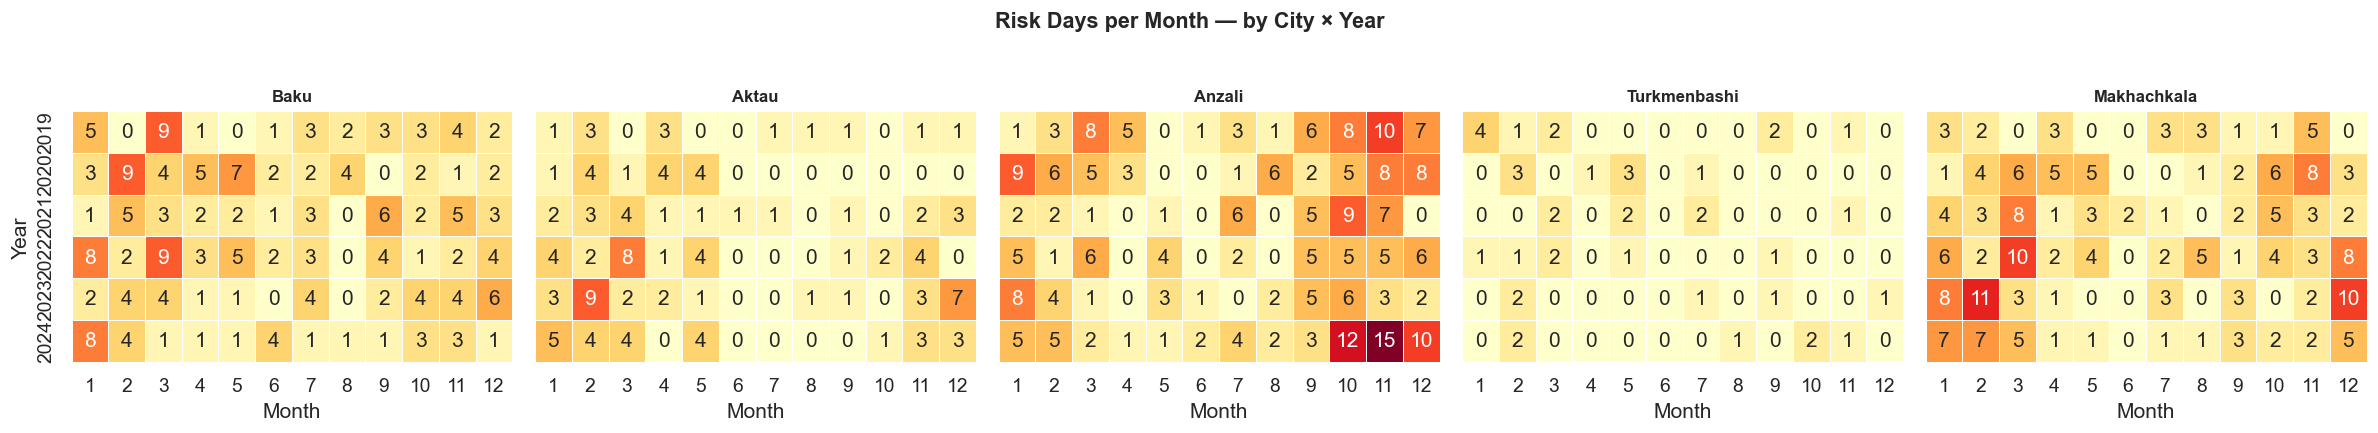

In [22]:
# Monthly heatmap of risk days (year × month per city)
fig, axes = plt.subplots(1, len(CITIES), figsize=(4 * len(CITIES), 3.5), sharey=True)

for ax, city in zip(axes, CITIES):
    q = conn.execute(f'''
        SELECT year, month, risk_days
        FROM analytics.monthly_summary
        WHERE city = '{city}'
    ''').fetchdf()
    if q.empty:
        continue
    pivot = q.pivot(index='year', columns='month', values='risk_days')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
                vmin=0, vmax=15, linewidths=0.3, cbar=False, ax=ax)
    ax.set_title(city, fontweight='bold', fontsize=10)
    ax.set_xlabel('Month'); ax.set_ylabel('Year' if city == list(CITIES)[0] else '')

fig.suptitle('Risk Days per Month — by City × Year',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day04_risk_heatmap.png', bbox_inches='tight')
plt.show()

In [23]:
# Force-reload the modules
import importlib
import src.cleaning
import src.features
importlib.reload(src.cleaning)
importlib.reload(src.features)

from src.cleaning import clean_raw_to_staging
from src.features import build_analytics_layer

print("Modules reloaded.")

Modules reloaded.


In [24]:
import sys, importlib
for mod in list(sys.modules):
    if mod.startswith('src.features'):
        del sys.modules[mod]

from src.features import build_analytics_layer

result = build_analytics_layer(conn)
print(result)

11:52:23  INFO      === Building analytics layer ===
11:52:23  INFO      Loaded 10960 staging rows
11:52:23  INFO      Running full feature pipeline...
11:52:23  INFO        ✓ seasonal features
11:52:23  INFO        ✓ temperature range
11:52:23  INFO        ✓ heating/cooling degree days
11:52:23  INFO        ✓ wave height proxy (SMB)
11:52:23  INFO        ✓ rolling features (7d, 30d)
11:52:23  INFO        ✓ anomaly scores
11:52:23  INFO        ✓ lag features
11:52:23  INFO      Feature pipeline complete — 64 columns total
11:52:23  INFO        Wrote analytics.daily_enriched: 10960 rows
11:52:23  INFO        Wrote analytics.monthly_summary: 360 rows
{'daily_enriched_rows': 10960, 'monthly_summary_rows': 360, 'feature_columns': 72}


In [25]:
print(run_query(conn, """
    SELECT
        year,
        COUNT(*)            AS days,
        SUM(is_risk_day)    AS risk_days,
        SUM(visibility_is_known) AS real_vis_days
    FROM analytics.daily_enriched
    GROUP BY year
    ORDER BY year
"""))

   year  days  risk_days  real_vis_days
0  2019  1825      129.0            0.0
1  2020  1830      157.0            0.0
2  2021  1825      126.0            0.0
3  2022  1825      161.0         1825.0
4  2023  1825      142.0         1825.0
5  2024  1830      156.0         1830.0


In [26]:
# Breakdown: which risk triggers fire most often?
trigger_mix = run_query(conn, '''
    SELECT
        city,
        SUM(wind_risk_days)       AS wind,
        SUM(gust_risk_days)       AS gust,
        SUM(precip_risk_days)     AS precip,
        SUM(snow_risk_days)       AS snow,
        SUM(wave_risk_days)       AS wave,
        SUM(visibility_risk_days) AS visibility,
        SUM(severe_fog_days)      AS severe_fog,
        SUM(risk_days)            AS any_risk
    FROM analytics.monthly_summary
    GROUP BY city
    ORDER BY city
''')
print('=== Risk trigger breakdown (total risk-days per trigger, per city) ===')
print(trigger_mix.to_string(index=False))

=== Risk trigger breakdown (total risk-days per trigger, per city) ===
        city  wind  gust  precip  snow  wave  visibility  severe_fog  any_risk
       Aktau  12.0  18.0    11.0   1.0  85.0         0.0        28.0     124.0
      Anzali   0.0   1.0   239.0   2.0   1.0         1.0        49.0     275.0
        Baku  21.0 104.0    20.0   1.0 169.0         0.0        18.0     211.0
 Makhachkala   0.0 133.0    37.0  11.0  44.0         1.0        49.0     219.0
Turkmenbashi   7.0  15.0     3.0   0.0  24.0         0.0         6.0      42.0


---
## 5 — Summary & Handoff

### ✅ Deliverables produced today

| File | Description |
|------|-------------|
| `src/cleaning.py` | `handle_missing_values`, `flag_outliers`, `winsorize_by_city`, `validate_date_continuity`, `clean_raw_to_staging` |
| `src/features.py` | `add_rolling_features`, `add_seasonal_features`, `add_temperature_range`, `add_degree_days`, `add_anomaly_scores`, `add_lag_features`, `add_wave_proxy`, `engineer_all_features`, `build_analytics_layer` |
| `reports/data_quality_report.md` | Formal data quality report |
| Tables populated | `staging.weather_daily`, `analytics.daily_enriched`, `analytics.monthly_summary` |

### 🔍 Key decisions logged

1. **Date window shortened to 2022–2024** — eliminates synthetic fog-proxy data that would have skewed the model
2. **Anzali-specific precipitation cap** — per-city winsorizing (Anzali = 60 mm; others 25–40 mm) prevents one climate from dominating cross-city stats
3. **Outliers flagged, not removed** — `_is_outlier` boolean columns preserved for modelling-time decisions
4. **Risk label source of truth lives in `risk_labeler._DEFAULT_THRESHOLDS`** — changed in one place only

### 📋 Day 5 handoff

- `analytics.monthly_summary` is your ML training table — 180 rows, one per (city × month)
- **180 samples is small** — use stratified k-fold CV with class stratification
- Class balance ratios reported above guide whether `HIGH_RISK_MONTH_THRESHOLD` (currently 5) needs adjusting
- Feature count per sample = ~60 after pivoting daily → monthly aggregates

---
*End of Day 4 — push, open PR, update project README.*

In [27]:
conn.close()
print('✅ Database connection closed. See you Day 5.')

✅ Database connection closed. See you Day 5.
